# Từ đặc trưng thống kê sang CNN thích nghi trên ảnh

Ở [Bài 02](02_features_and_lr.ipynb), mô hình Logistic Regression kết hợp 32 đặc trưng thống kê về dung lượng, màu sắc, chi tiết kết cấu và bố cục trung tâm so với vùng biên. Dù đã bổ sung gradient và thống kê vùng, một vector 32 chiều cố định vẫn nén toàn bộ ảnh thành các giá trị tóm tắt.

Mạng nơ-ron tích chập (CNN) có thể học các biểu diễn trực tiếp từ mảng điểm ảnh. Khởi đầu với mạng DenseNet-121 đã được huấn luyện trước trên tập ImageNet, ta đứng trước câu hỏi: chỉ huấn luyện lớp phân loại (head) trên các đặc trưng có sẵn đã đủ chưa, hay cần mở khóa để toàn bộ mạng thích nghi với bài toán phân biệt ảnh giả này?

Notebook này so sánh hai phương án đó trên cùng tập kiểm định Fold 0 với cùng đầu vào `center60`. Trước khi so sánh, ta xem một phản ví dụ về giới hạn của thống kê, phân tách rõ vùng nhìn với các lớp được học, và minh họa một bước tính toán của mạng.

In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from kmd.core import PACKAGE, read_csv, split_fold, metric, read_json
from kmd.config import Config
from kmd.presets import get_preset_config
from kmd.data import Pairs, make_loader
from kmd.models import model_for, train_mode, head_name, logits, objective
from kmd.training import train_step
from kmd.pipeline import prepare_development, load_session, train_cnn_fold, aligned_predictions
from kmd.teaching import resolve_data_roots, show_pair_images

KMD_SMOKE = os.environ.get('KMD_SMOKE', '0') == '1'
KMD_RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
RUN_ID = f"{KMD_RUN_ID}_smoke" if (KMD_SMOKE and not KMD_RUN_ID.endswith('_smoke')) else KMD_RUN_ID

data_root, test_root = resolve_data_roots(TASK_ROOT)
if not data_root.is_dir() or not (data_root / 'pairs.csv').is_file():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục dữ liệu huấn luyện tại '{data_root}'. "
        "Vui lòng thiết lập biến môi trường DATA_ROOT trỏ đến thư mục chứa 'pairs.csv' và 'images/'."
    )

if not torch.cuda.is_available():
    raise RuntimeError(
        "Huấn luyện mạng CNN yêu cầu thiết bị hỗ trợ CUDA. "
        "Vui lòng sử dụng máy có GPU hoặc chạy các mô hình baseline tại bài 01 và 02."
    )

dev_frame = prepare_development(data_root)
session_dir = load_session(RUN_ID, data_root)
print(f"Thư mục dự án: {TASK_ROOT}")
print(f"Phiên làm việc: {session_dir.name} (smoke={KMD_SMOKE})")
print(f"Thiết bị tính toán: {torch.cuda.get_device_name(0)}")
print(f"Tổng số cặp phát triển: {len(dev_frame)}")

Thư mục dự án: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh
Phiên làm việc: lesson_full_v5_20260920 (smoke=False)
Thiết bị tính toán: NVIDIA GeForce RTX 5060 Ti
Tổng số cặp phát triển: 800


## 1. Giới hạn của 32 đặc trưng và phản ví dụ bố cục không gian

Ở Bài 02, bộ 32 đặc trưng đã có gradient Sobel, Laplacian, residual và phân vùng trung tâm/biên. Tuy nhiên, các đại lượng này vẫn là các con số tóm tắt trung bình hoặc độ lệch chuẩn.

Xét hai ma trận điểm ảnh kích thước 2x2:

$$A = \begin{bmatrix} 0 & 0 \\ 1 & 1 \end{bmatrix}, \qquad B = \begin{bmatrix} 0 & 1 \\ 0 & 1 \end{bmatrix}$$

Cả hai ma trận đều có hai số 0 và hai số 1. Giá trị trung bình bằng nhau (0.50), độ lệch chuẩn bằng nhau (0.50), và biểu đồ phân bố độ sáng giống hệt nhau. Tuy nhiên, ma trận $A$ có biên nằm ngang, còn ma trận $B$ có biên thẳng đứng. Bất kỳ hàm trích xuất nào chỉ gom các điểm ảnh thành các thống kê giá trị đều không phân biệt được hai cấu trúc này.

Ví dụ này chỉ nói về mean, standard deviation và histogram, không chứng minh toàn bộ 32 đặc trưng trùng nhau.

Mạng CNN sử dụng các bộ lọc tích chập quét qua từng vùng lân cận, lưu giữ thông tin về hướng biên và sự sắp xếp tương đối giữa các điểm ảnh.

In [2]:
mat_a = np.array([[0, 0], [1, 1]], dtype=float)
mat_b = np.array([[0, 1], [0, 1]], dtype=float)

print("Ma trận A (biên ngang):\n", mat_a)
print("Ma trận B (biên dọc):\n", mat_b)
print(f"Trung bình:  A = {mat_a.mean():.4f}, B = {mat_b.mean():.4f}")
print(f"Độ lệch chuẩn: A = {mat_a.std():.4f}, B = {mat_b.std():.4f}")
print(f"Histogram:   A = {np.bincount(mat_a.astype(int).flatten())}, B = {np.bincount(mat_b.astype(int).flatten())}")
print("Nhận xét: Các thống kê giá trị hoàn toàn trùng khớp dù cấu trúc không gian khác nhau.")

Ma trận A (biên ngang):
 [[0. 0.]
 [1. 1.]]
Ma trận B (biên dọc):
 [[0. 1.]
 [0. 1.]]
Trung bình:  A = 0.5000, B = 0.5000
Độ lệch chuẩn: A = 0.5000, B = 0.5000
Histogram:   A = [2 2], B = [2 2]
Nhận xét: Các thống kê giá trị hoàn toàn trùng khớp dù cấu trúc không gian khác nhau.


## 2. Vùng nhìn Center60 và phân tách hai khái niệm độc lập

Cần phân biệt rõ hai khái niệm hoàn toàn độc lập với nhau:

- Vùng nhìn đầu vào (input view): Cách cắt và co giãn ảnh trước khi đưa vào mạng. `center60` cắt 60% mỗi chiều (từ 20% đến 80% chiều cao và chiều rộng), tương đương một vùng khoảng 307x307 trên ảnh 512x512, rồi co giãn (resize) về kích thước chuẩn 224x224.
  Tỷ lệ 60% mỗi chiều tương đương diện tích $0.6 \times 0.6 = 0.36$ (khoảng 36% diện tích toàn ảnh), không phải 60% diện tích ảnh. Con số 60% này là một heuristic ban đầu dựa trên giả định khuôn mặt thường nằm ở giữa ảnh chân dung; nó chưa được chứng minh là tối ưu so với 50% hay 70%.
- Các lớp tham số được học (trainable layers): Chỉ huấn luyện lớp phân loại (`frozen`) hay cập nhật toàn bộ mạng (`full fine-tune`).

Cả hai mô hình `frozen` và `center60` (full) đều dùng chung một đầu vào `center60`. Việc so sánh hai cấu hình này nhằm đánh giá tác động của việc cập nhật biểu diễn trong mạng, khi giữ nguyên toàn bộ vùng nhìn đầu vào.

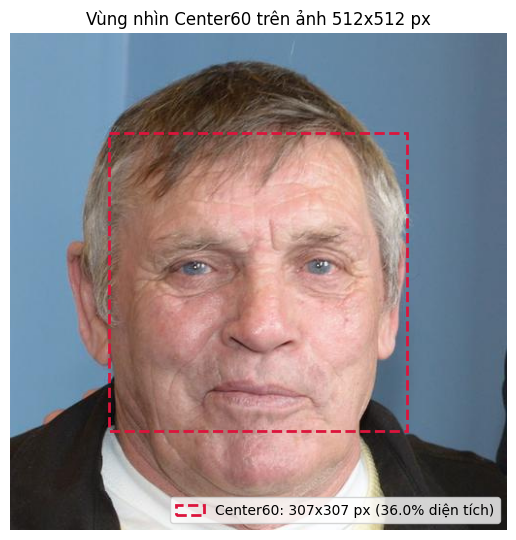

Tọa độ cắt Center60: x=[102, 409], y=[102, 409]
Vùng cắt 307x307 px sau đó được co giãn (resize) về 224x224 px đưa vào mạng.


In [3]:
tr_fold0, va_fold0 = split_fold(dev_frame, fold=0)
sample_row = tr_fold0.sort_values('pair_id').iloc[0]
sample_path = data_root / sample_row.image_0

with Image.open(sample_path) as img:
    im = img.convert('RGB')
    w, h = im.size

cw, ch = int(w * 0.6), int(h * 0.6)
c_left, c_top = (w - cw) // 2, (h - ch) // 2

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(im)
rect = plt.Rectangle(
    (c_left, c_top), cw, ch,
    linewidth=2, edgecolor='crimson', facecolor='none', linestyle='--',
    label=f'Center60: {cw}x{ch} px ({cw*ch/(w*h)*100:.1f}% diện tích)'
)
ax.add_patch(rect)
ax.set_title(f"Vùng nhìn Center60 trên ảnh {w}x{h} px")
ax.legend(loc='lower right')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Tọa độ cắt Center60: x=[{c_left}, {c_left + cw}], y=[{c_top}, {c_top + ch}]")
print(f"Vùng cắt {cw}x{ch} px sau đó được co giãn (resize) về 224x224 px đưa vào mạng.")

## 3. Kiến trúc Backbone, Head và hàm mất mát Binary Cross-Entropy

Mô hình được tổ chức thành hai khối rõ ràng:
- Backbone (DenseNet-121): Nhận ảnh đầu vào kích thước $3 \times 224 \times 224$, xuất ra vector đặc trưng 1.024 chiều. Trọng số ban đầu được lấy từ mô hình đã huấn luyện trước trên ImageNet.
- Head: Một lớp tuyến tính `nn.Linear(1024, 1)` chuyển đổi vector đặc trưng thành một điểm số vô hướng (scalar logit) $s$ cho từng ảnh.

Khi xử lý một cặp ảnh $(image_0, image_1)$:
- Mạng tính hai điểm số $s_0$ và $s_1$.
- Xác suất ảnh bên phải là ảnh giả được tính qua hiệu hai điểm số:

$$p = \sigma(s_1 - s_0) = \frac{1}{1 + e^{-(s_1 - s_0)}}$$

- Nhãn cặp $y \in \{0, 1\}$ được tách thành hai nhãn ảnh: $image_0$ có nhãn $1 - y$ và $image_1$ có nhãn $y$. Hàm mất mát Binary Cross-Entropy (BCE) được tính trực tiếp trên logits từng ảnh:

$$\mathcal{L} = \frac{1}{2}[\text{BCEWithLogits}(s_0, 1 - y) + \text{BCEWithLogits}(s_1, y)]$$

Loss trên batch là trung bình tiếp trên các cặp. Hai lựa chọn huấn luyện cần biết:
- Warmup: Lớp head được khởi tạo ngẫu nhiên, trong khi backbone đã có các đặc trưng tốt từ ImageNet. Để head có thời gian thích nghi trước khi tác động vào backbone, preset chọn 2 epoch đầu tiên chỉ huấn luyện lớp head với learning rate $3 \times 10^{-4}$, sau đó mới mở toàn bộ backbone với learning rate nhỏ hơn nhiều ($2 \times 10^{-5}$).
- BatchNorm ở chế độ eval: Các lớp BatchNorm giữ nguyên running mean và running variance từ ImageNet. Trong bài này, batch huấn luyện nhỏ (microbatch 24 hoặc 8). Giữ thống kê BatchNorm là một lựa chọn nhằm hạn chế biến thiên ở batch nhỏ; bài này chưa đối chứng riêng lựa chọn đó, trong khi các tham số affine (gamma, beta) vẫn có thể được học khi fine-tune.

In [4]:
c_demo = Config(**read_json(TASK_ROOT / 'configs/center60.json'))
device = 'cuda' if torch.cuda.is_available() else 'cpu'

demo_model, _ = model_for(c_demo, device=device, pretrained=True)
demo_model.train()
train_mode(demo_model, c_demo, epoch=1)

demo_ds = Pairs(tr_fold0.sort_values('pair_id').head(2), data_root, c_demo, training=True, epoch=1)
demo_x, demo_y = next(iter(make_loader(demo_ds, batch=2)))
demo_x = demo_x.to(device)
demo_y = demo_y.to(device)

with torch.no_grad():
    img_logits = logits(demo_model, demo_x, c_demo)
    s0, s1 = img_logits[:, 0], img_logits[:, 1]
    p_pair = torch.sigmoid(s1 - s0)
    image_targets = torch.stack([1 - demo_y, demo_y], dim=1)
    loss_val = torch.nn.functional.binary_cross_entropy_with_logits(img_logits, image_targets)
    torch.testing.assert_close(loss_val, objective(img_logits, demo_y, c_demo))

print("Minh họa phép tính với head mới khởi tạo, không phải kết quả đánh giá:")
print(f"- Kích thước tensor đầu vào demo_x: {list(demo_x.shape)}")
print(f"- Nhãn cặp thực tế demo_y: {demo_y.cpu().numpy()}")
print(f"- Điểm số logits từng ảnh [s0, s1]:\n{img_logits.cpu().numpy()}")
print(f"- Xác suất cặp p = sigmoid(s1 - s0): {p_pair.cpu().numpy()}")
print(f"- Giá trị loss BCE: {loss_val.item():.4f}")

h_name = head_name(c_demo)
demo_opt = torch.optim.AdamW([
    {'params': [p for n, p in demo_model.named_parameters() if not n.startswith(h_name)], 'lr': c_demo.backbone_lr},
    {'params': [p for n, p in demo_model.named_parameters() if n.startswith(h_name)], 'lr': c_demo.head_lr},
], weight_decay=c_demo.weight_decay)
demo_opt.zero_grad(set_to_none=True)

step_loss, preclip_norm = train_step(
    model=demo_model, x=demo_x, y=demo_y, optimizer=demo_opt,
    c=c_demo, target_batch=2, clip_grad=5.0, perform_update=True, device=device
)
print(f"- Thực hiện train_step: Loss = {step_loss:.4f}, Gradient norm = {preclip_norm:.4f}")

del demo_model, demo_opt
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Minh họa phép tính với head mới khởi tạo, không phải kết quả đánh giá:
- Kích thước tensor đầu vào demo_x: [2, 2, 1, 3, 224, 224]
- Nhãn cặp thực tế demo_y: [1. 1.]
- Điểm số logits từng ảnh [s0, s1]:
[[0.03718677 0.54265404]
 [0.67248815 0.4339568 ]]
- Xác suất cặp p = sigmoid(s1 - s0): [0.62374336 0.44064832]
- Giá trị loss BCE: 0.6886
- Thực hiện train_step: Loss = 0.6889, Gradient norm = 3.4789


## 4. Huấn luyện đối chứng trên Fold 0: Frozen so với Full fine-tune

Ta tiến hành so sánh hai cấu hình trên cùng tập dữ liệu kiểm định Fold 0 (267 cặp):
- `frozen`: Đóng băng toàn bộ các tầng tích chập của DenseNet-121, chỉ huấn luyện lớp Linear head. Thí nghiệm này kiểm tra xem các đặc trưng nguyên bản từ ImageNet có đủ để giải quyết bài toán hay không.
- `center60`: Sau 2 epoch warmup lớp head, toàn bộ backbone được mở khóa để học thích nghi với dữ liệu bài toán.

Cả hai cấu hình đều sử dụng cùng đầu vào center60, cùng kích thước 224x224, cùng hàm mất mát BCE và cùng lịch trình tối ưu hóa. Điểm khác biệt duy nhất là các tầng tham số được phép cập nhật.

In [5]:
folder_frozen, res_frozen = train_cnn_fold('frozen', dev_frame, data_root, session_dir, fold=0, smoke=KMD_SMOKE)
folder_full, res_full = train_cnn_fold('center60', dev_frame, data_root, session_dir, fold=0, smoke=KMD_SMOKE)

df_res = pd.DataFrame([
    {'Mô hình': '1. Frozen Backbone (Chỉ huấn luyện Head)', **res_frozen['metrics']},
    {'Mô hình': '2. Full Fine-tuning (center60)', **res_full['metrics']},
])
print("Kết quả đối chứng trên tập kiểm định Fold 0:")
display_cols = ['Mô hình', 'macro_f1', 'accuracy', 'log_loss', 'errors']
print(df_res[display_cols].to_string(index=False))

frozen_s20260917_f0: epoch 1/24, loss=0.7095, current_F1=0.5802, best=0.5802


frozen_s20260917_f0: epoch 2/24, loss=0.6766, current_F1=0.6779, best=0.6779


frozen_s20260917_f0: epoch 3/24, loss=0.6506, current_F1=0.7416, best=0.7416


frozen_s20260917_f0: epoch 4/24, loss=0.6300, current_F1=0.7602, best=0.7602


frozen_s20260917_f0: epoch 5/24, loss=0.6138, current_F1=0.7676, best=0.7676


...

center60_s20260917_f0: epoch 18/24, loss=0.1914, current_F1=0.9588, best=0.9700


center60_s20260917_f0: epoch 19/24, loss=0.0227, current_F1=0.9700, best=0.9700


center60_s20260917_f0: epoch 20/24, loss=0.0487, current_F1=0.9625, best=0.9700


center60_s20260917_f0: epoch 21/24, loss=0.0175, current_F1=0.9663, best=0.9700


Kết quả đối chứng trên tập kiểm định Fold 0:
                                 Mô hình  macro_f1  accuracy  log_loss  errors
1. Frozen Backbone (Chỉ huấn luyện Head)  0.846407  0.846442  0.405873      41
          2. Full Fine-tuning (center60)  0.970037  0.970037  0.142080       8


## 5. Phân tích sự chuyển dịch lỗi khi mở khóa Backbone

Khi cho phép cập nhật toàn bộ trọng số backbone, mạng có thể sửa được nhiều lỗi phán đoán mà mô hình Frozen mắc phải. Tuy nhiên, việc điều chỉnh hàng triệu tham số cũng có nguy cơ làm sai một số cặp mà trước đó mô hình Frozen đã đoán đúng.

Ta bóc tách trực tiếp trên dự đoán của Fold 0:
- Mẫu được sửa đúng (`fixed_cases`): Frozen đoán sai nhưng Full fine-tune đoán đúng.
- Mẫu bị làm sai thêm (`new_errors`): Frozen đoán đúng nhưng Full fine-tune đoán sai.
- Độ chênh lệch giảm lỗi ròng: `net_gain = fixed_cases - new_errors`.

Thống kê chuyển dịch lỗi trên tập kiểm định Fold 0:
- Tổng số lỗi của Frozen:               41
- Tổng số lỗi của Full fine-tuning:      8
- Số mẫu được sửa đúng nhờ Full:        36
- Số mẫu bị làm sai thêm do Full:       3
- Độ giảm lỗi ròng:                     33 mẫu


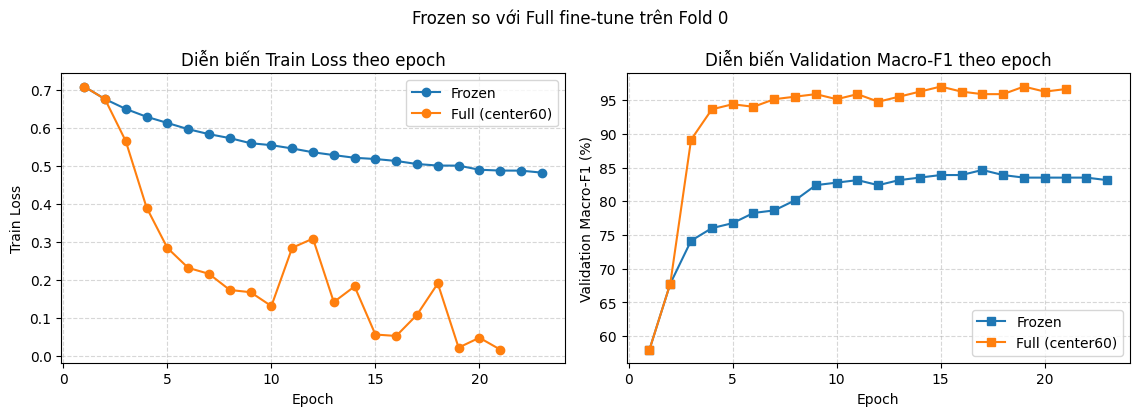

In [6]:
p_f_df = read_csv(folder_frozen / 'development.csv').rename(columns={'y': 'fake_position', 'fold': 'inner_fold'})
p_c_df = read_csv(folder_full / 'development.csv').rename(columns={'y': 'fake_position', 'fold': 'inner_fold'})

p_f = aligned_predictions(p_f_df, va_fold0)
p_c = aligned_predictions(p_c_df, va_fold0)

y_true = va_fold0.fake_position.to_numpy()
corr_f = (p_f.p.to_numpy() >= 0.5) == y_true
corr_c = (p_c.p.to_numpy() >= 0.5) == y_true

fixed_cases = (~corr_f) & corr_c
new_errors = corr_f & (~corr_c)

print("Thống kê chuyển dịch lỗi trên tập kiểm định Fold 0:")
print(f"- Tổng số lỗi của Frozen:               {np.sum(~corr_f)}")
print(f"- Tổng số lỗi của Full fine-tuning:      {np.sum(~corr_c)}")
print(f"- Số mẫu được sửa đúng nhờ Full:        {np.sum(fixed_cases)}")
print(f"- Số mẫu bị làm sai thêm do Full:       {np.sum(new_errors)}")
print(f"- Độ giảm lỗi ròng:                     {np.sum(fixed_cases) - np.sum(new_errors)} mẫu")

# Vẽ đường cong học tập từ history.csv
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for label, folder in [('Frozen', folder_frozen), ('Full (center60)', folder_full)]:
    hist_path = folder / 'history.csv'
    if hist_path.is_file():
        hist = pd.read_csv(hist_path)
        axes[0].plot(hist.epoch, hist.train_loss, marker='o', label=label)
        axes[1].plot(hist.epoch, hist.dev_f1 * 100, marker='s', label=label)

axes[0].set(xlabel='Epoch', ylabel='Train Loss', title='Diễn biến Train Loss theo epoch')
axes[1].set(xlabel='Epoch', ylabel='Validation Macro-F1 (%)', title='Diễn biến Validation Macro-F1 theo epoch')
for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
fig.suptitle("SMOKE: 64 cặp train/fold, 2 epoch" if KMD_SMOKE else "Frozen so với Full fine-tune trên Fold 0")
plt.tight_layout()
plt.show()

## 6. Đọc kết quả và đặt câu hỏi về điểm ảnh gốc

Hãy đọc kết quả thực tế từ bảng số liệu và đường cong học tập:
- So sánh số lỗi và chỉ số Macro-F1: nếu Full fine-tune có F1 cao hơn và giảm lỗi ròng so với Frozen, kết quả ủng hộ việc điều chỉnh các trọng số của backbone cho dữ liệu của bài toán này.
- Tuy nhiên, kết quả trên Fold 0 là bằng chứng cục bộ trên 267 cặp kiểm định; nó chưa chứng minh mô hình sẽ giữ nguyên thứ hạng trên toàn bộ 3 fold OOF.

Về mặt xử lý ảnh, cả `frozen` và `center60` đều cắt một vùng khoảng 307x307 rồi co giãn về 224x224. Thao tác nội suy làm thay đổi giá trị điểm ảnh gốc. Nếu các dấu vết giả mạo nằm ở các chi tiết vi mô, việc co giãn ảnh có thể đã làm suy giảm tín hiệu.

Liệu việc giữ nguyên điểm ảnh gốc có giúp mô hình nhận diện tốt hơn không?

[Bài 04](04_native_and_resampling.ipynb) thiết kế một phép thử đối chứng để kiểm tra câu hỏi đó: giữ nguyên điểm ảnh gốc 1:1 (Native) so với qua phép nội suy co giãn (Resampled) trong cùng một vùng nhìn.